# Default Data Demonstration

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/WISDEM/WOMBAT/main?filepath=examples)

In this example, we'll show what each of the reference plants look like and what results they yield when simulated.

```{important}
The land-based data are expiremental, and should only be used as a starting point for
developing a more robust simulation. Please see the
[default data section of the user guide for further details](index.md#default-data)
```

## Imports

In [1]:
from time import perf_counter

import numpy as np
import pandas as pd

from wombat import Simulation
from wombat.utilities import plot
from wombat.core.library import DEFAULT_DATA

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 20)
pd.options.display.float_format = "{:,.2f}".format

## Initialize the simulations

In [2]:
SEED = 48

lbw_sim = Simulation(DEFAULT_DATA, "base_lbw.yaml", random_seed=SEED)
#osw_fixed_sim = Simulation(DEFAULT_DATA, "base_osw_fixed.yaml", random_seed=SEED)
#osw_floating_sim = Simulation(DEFAULT_DATA, "base_osw_floating.yaml", random_seed=SEED)

### View the farms

Using the plotting library, we can observe the layout for each of the farms

N turbines: 57, N substations: 1


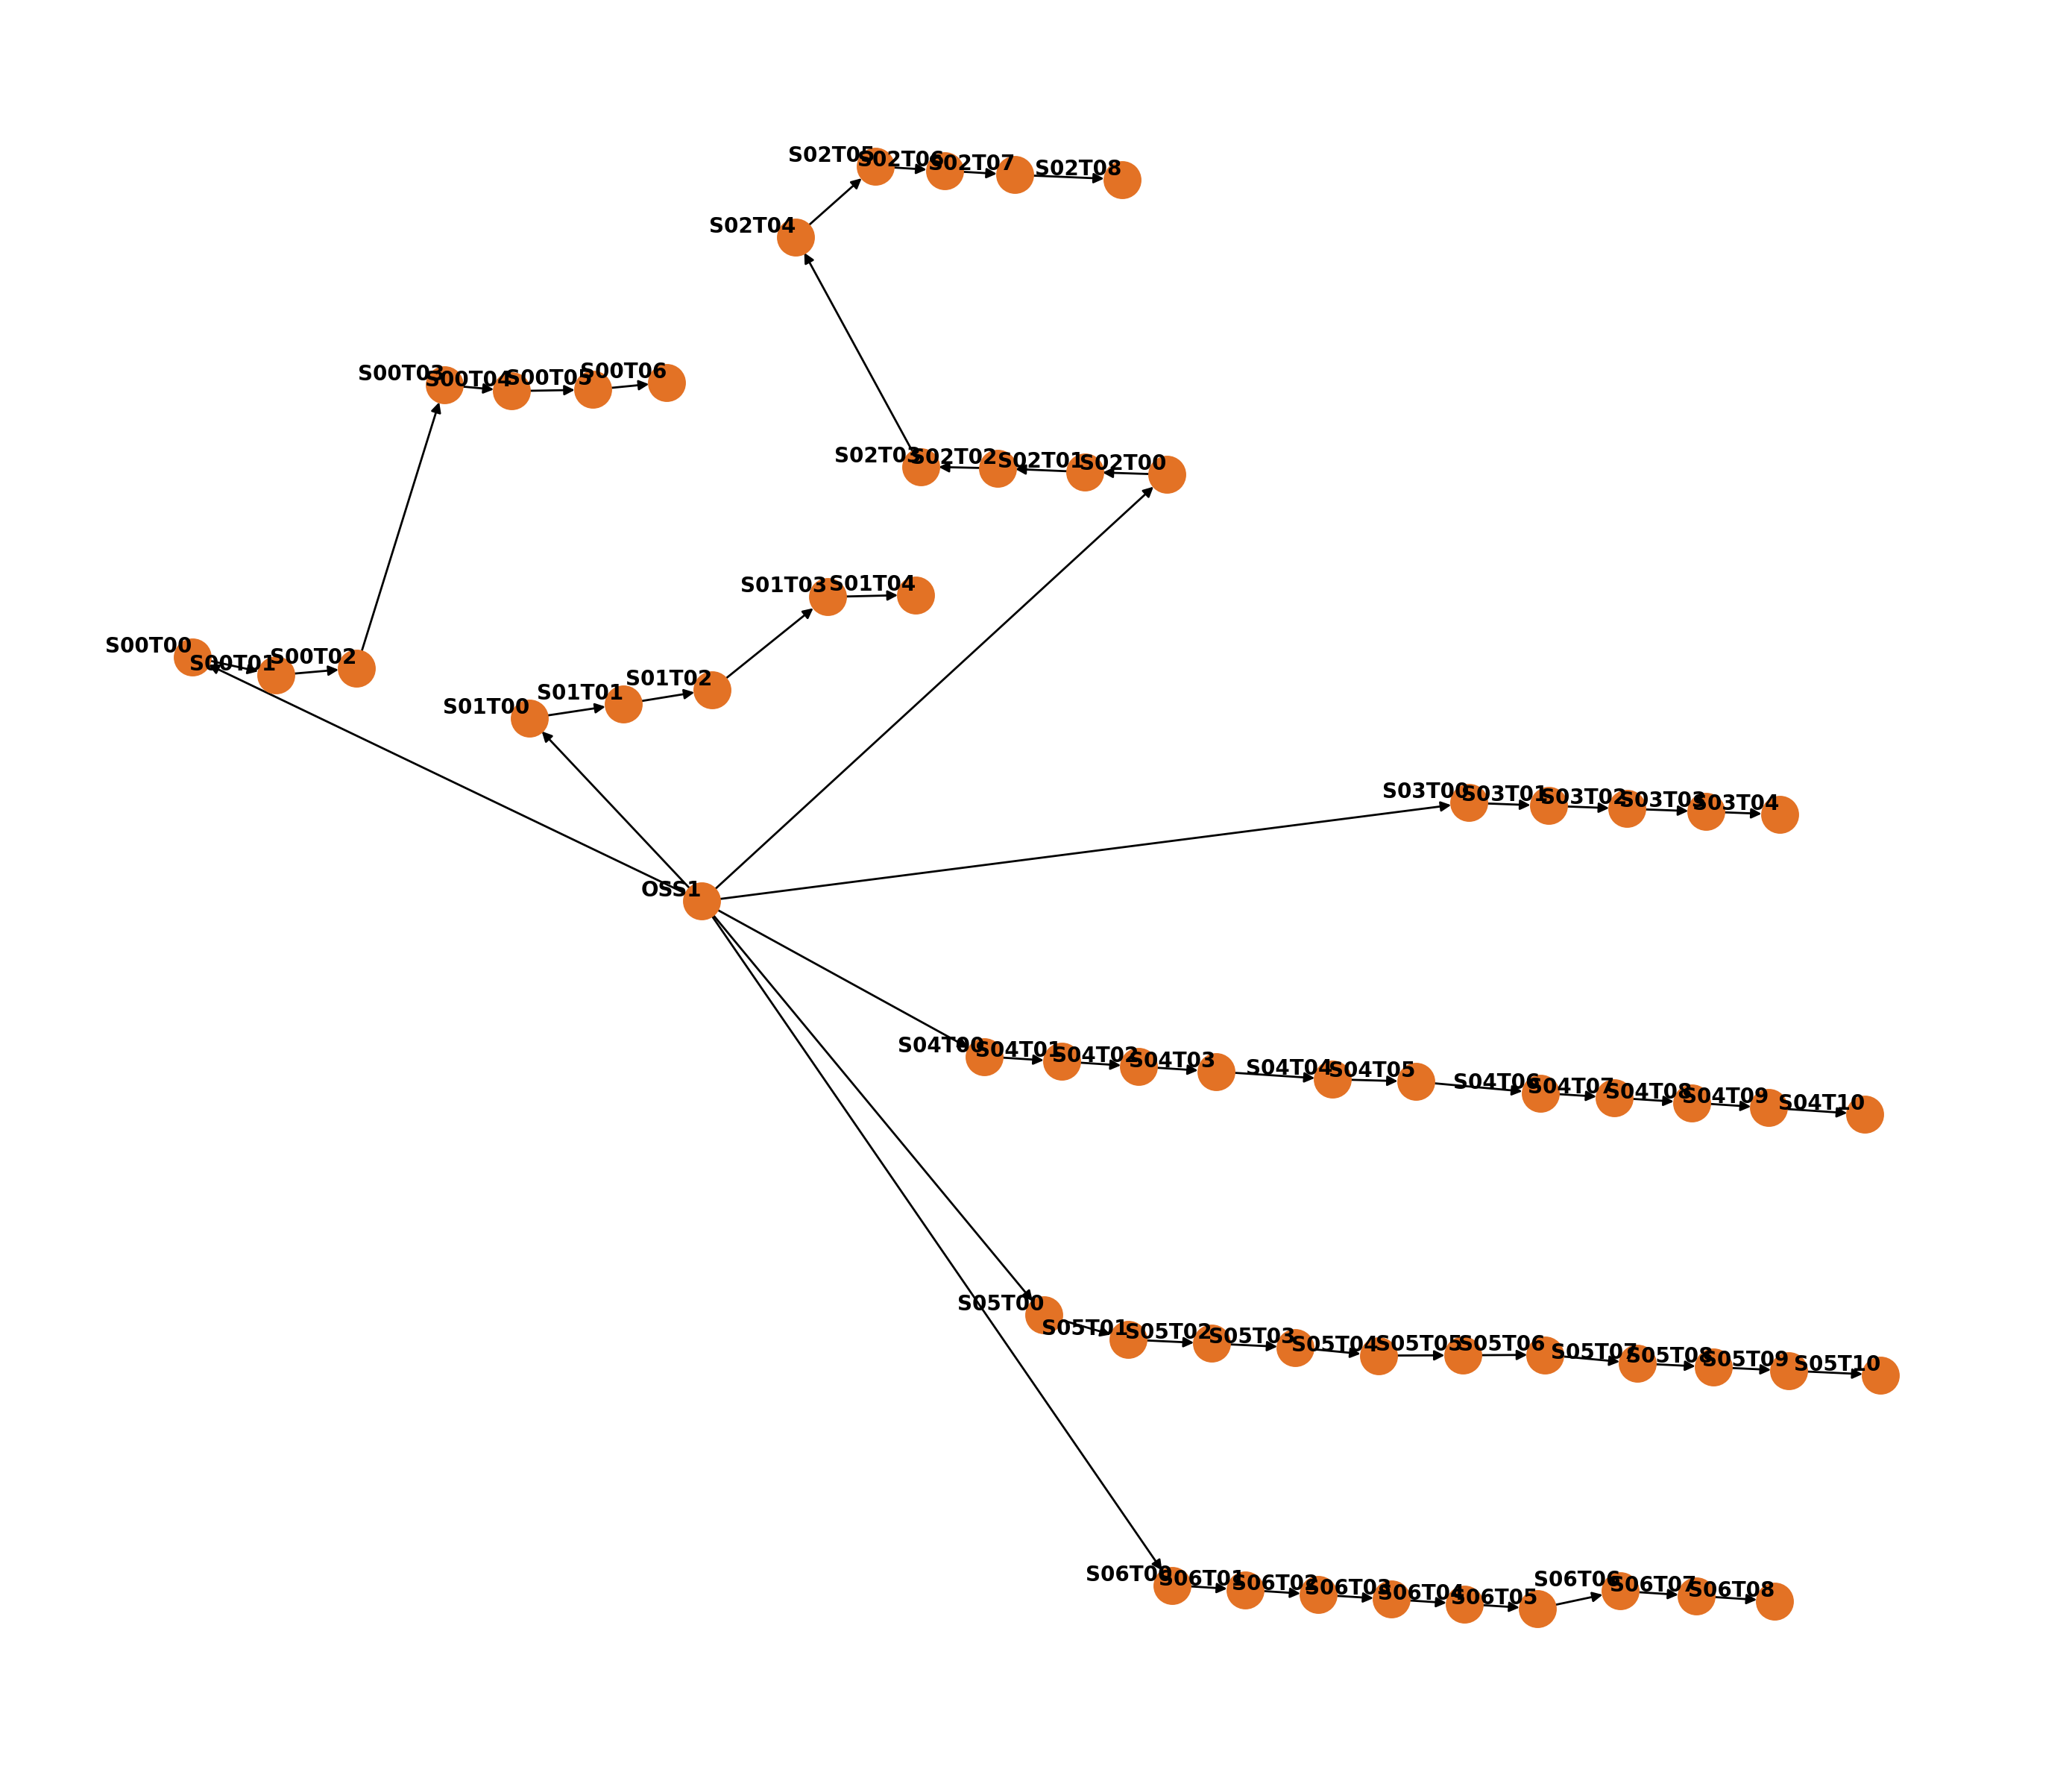

In [3]:
print(
    f"N turbines: {len(lbw_sim.windfarm.turbine_id)}, N substations: {len(lbw_sim.windfarm.substation_id)}"
)
plot.plot_farm_layout(lbw_sim.windfarm)

In [4]:
#print(
#    f"N turbines: {len(osw_fixed_sim.windfarm.turbine_id)}, N substations: {len(osw_fixed_sim.windfarm.substation_id)}"
#)
#plot.plot_farm_layout(osw_fixed_sim.windfarm)

In [5]:
#print(
#    f"N turbines: {len(osw_floating_sim.windfarm.turbine_id)}, N substations: {len(osw_floating_sim.windfarm.substation_id)}"
#)
#plot.plot_farm_layout(osw_floating_sim.windfarm)

## Run the simulations

Now we can run all three simulations, delete the simulation log files, and view the run time for
each simulation.

In [6]:
start = perf_counter()
lbw_sim.run(delete_logs=False, save_metrics_inputs=True)
run_time = perf_counter() - start
print(f"Run time: {run_time // 60} minutes {run_time % 60:.1f} seconds")

#start = perf_counter()
#osw_fixed_sim.run(delete_logs=True, save_metrics_inputs=False)
#run_time = perf_counter() - start
#print(f"Run time: {run_time // 60} minutes {run_time % 60:.1f} seconds")

#start = perf_counter()
#osw_floating_sim.run(delete_logs=True, save_metrics_inputs=False)
#run_time = perf_counter() - start
#print(f"Run time: {run_time // 60} minutes {run_time % 60:.1f} seconds")

Run time: 2.0 minutes 0.6 seconds


### Gather the results

First we will simplify the process of getting results, ensure that all simulations are
20 years, and gather the capacities.

In [7]:
metrics_lbw = lbw_sim.metrics
#metrics_osw_fixed = osw_fixed_sim.metrics
#metrics_osw_floating = osw_floating_sim.metrics

years_check = (
    lbw_sim.env.simulation_years,
#    osw_fixed_sim.env.simulation_years,
#    osw_floating_sim.env.simulation_years,
)

years = 25
print(f"All are 25 years: {all(x == years for x in years_check)}")

capacities = [  # MW
    metrics_lbw.project_capacity,
#    metrics_osw_fixed.project_capacity,
#    metrics_osw_floating.project_capacity,
]

columns = ["Metric", "Units", "Land-Based"]
sort_order = [
    "Project Capacity",
    "Production Based Availability",
    "Total OpEx",
    "Materials",
    "Direct Labor",
    "Fixed Costs (operations, indirect labor, etc.)",
    "Service Equipment",
    "Truck 1",
    "Truck 2",
    "Truck 3",
    "Crawler Crane - 1350 tonnes",
]

All are 25 years: True


Now, we can gather some of the high level availability and cost statistics for each
of the base scenarios.

In [8]:
capacity = pd.DataFrame(
    [["Project Capacity", "MW"] + capacities], columns=columns
).set_index(["Metric", "Units"])

availability = [
    "Production Based Availability",
    "%",
    metrics_lbw.production_based_availability("project", "windfarm").squeeze() * 100,
#    metrics_osw_fixed.production_based_availability("project", "windfarm").squeeze()
#    * 100,
#    metrics_osw_floating.production_based_availability("project", "windfarm").squeeze()
#    * 100,
]
availability = pd.DataFrame([availability], columns=columns).set_index(
    ["Metric", "Units"]
)

In [9]:
opex = (
    metrics_lbw.opex("project", "windfarm")
    .rename({0: "Land-Based"}).T
    #.join(metrics_osw_fixed.opex("project", "windfarm").rename({0: "OSW-Fixed"}).T)
#    .join(
#        metrics_osw_floating.opex("project", "windfarm").rename({0: "OSW-Floating"}).T
#    )
    / years
    / (np.array(capacities) * 1000)
)
opex.index = [
    "Fixed Costs (operations, indirect labor, etc.)",
    "Port Fees",
    "Service Equipment",
    "Direct Labor",
    "Materials",
    "Total OpEx",
]
opex["Units"] = "$/kw/yr"
opex = opex.set_index("Units", append=True).iloc[::-1]

In [10]:
equipment = (
    metrics_lbw.equipment_costs("project", by_equipment=True)
    .rename({0: "Land-Based"}).T
    #.join(
    #    metrics_osw_fixed.equipment_costs("project", by_equipment=True)
    #    .rename({0: "OSW-Fixed"})
    #    .T,
    #    how="outer",
    #)
    #.join(
    #    metrics_osw_floating.equipment_costs("project", by_equipment=True)
    #    .rename({0: "OSW-Floating"})
    #    .T,
    #    how="outer",
    #)
    .fillna(0.0)
    / years
    / (np.array(capacities) * 1000)
)
equipment["Units"] = "$/kw/yr"
equipment = equipment.set_index("Units", append=True)

With each of the core costs gathered, we can combine them into a single DataFrame and
view them.

In [11]:
results = pd.concat([capacity, availability, opex, equipment]).loc[sort_order]
results

,,Land-Based
,Units,
Project Capacity,MW,199.50
Production Based Availability,%,94.22
Total OpEx,$/kw/yr,28.76
Materials,$/kw/yr,2.12
Direct Labor,$/kw/yr,0.00
"Fixed Costs (operations, indirect labor, etc.)",$/kw/yr,18.81
Service Equipment,$/kw/yr,7.83
Truck 1,$/kw/yr,0.03
Truck 2,$/kw/yr,0.03


In [12]:
results

,,Land-Based
,Units,
Project Capacity,MW,199.50
Production Based Availability,%,94.22
Total OpEx,$/kw/yr,28.76
Materials,$/kw/yr,2.12
Direct Labor,$/kw/yr,0.00
"Fixed Costs (operations, indirect labor, etc.)",$/kw/yr,18.81
Service Equipment,$/kw/yr,7.83
Truck 1,$/kw/yr,0.03
Truck 2,$/kw/yr,0.03


In [13]:
lbw_sim.metrics.request_summary()

total_requests  canceled_requests  \
subassembly     task                                                       
blades          major repair                       20                  0   
                major replacement                   4                  0   
gearbox         major repair                       98                  1   
                major replacement                  30                  0   
generator       major repair                       36                  3   
                major replacement                  32                  0   
main_bearing    annual oil change                 399                  1   
                major replacement                   9                  0   
main_shaft      major replacement                  13                  0   
pitch_bearing   major replacement                   6                  0   
transformer     oss annual inspection              24                  0   
                oss major repair                    1                  0   
                oss minor repair                    6                  0   
wtg_transformer major replacement                   6                  0   

                                       incomplete_requests  completed_requests  
subassembly     task                                                            
blades          major repair                             9                  11  
                major replacement                        0                   4  
gearbox         major repair                            22                  75  
                major replacement                        4                  26  
generator       major repair                             4                  29  
                major replacement                        2                  30  
main_bearing    annual oil change                      341                  57  
                major replacement                        1                   8  
main_shaft      major replacement                        1                  12  
pitch_bearing   major replacement                        1                   5  
transformer     oss annual inspection                    6                  18  
                oss major repair                         1                   0  
                oss minor repair                         0                   6  
wtg_transformer major replacement                        1                   5

In [14]:
events_df = lbw_sim.env.load_events_log_dataframe()

In [15]:
import pandas as pd

def summarize_crane_costs_per_replacement(events_df, crane_agent="Crawler Crane - 1350 tonnes"):
    """
    Summarizes crane costs per main bearing major replacement event
    from a WOMBAT events log dataframe, including mobilization costs
    which are matched to each replacement by nearest date.
    """

    events_df = events_df.copy()
    events_df["env_datetime"] = pd.to_datetime(events_df["env_datetime"])

    # --- Crane major replacement rows (have request_id) ---
    crane = events_df[
        (events_df["reason"] == "major replacement") &
        (events_df["agent"] == crane_agent)
    ].copy()

    # Start date, turbine ID, and subassembly per replacement event
    start_dates = crane.groupby("request_id")["env_datetime"].min().rename("start_date")
    turbine_ids = crane.groupby("request_id")["system_id"].first().rename("turbine_id")
    subassembly = crane.groupby("request_id")["part_name"].first().rename("subassembly")

    # Sum costs and duration per request_id
    summary = crane.groupby("request_id").agg(
        total_duration_hrs=("duration", "sum"),
        equipment_cost_total=("equipment_cost", "sum"),
        materials_cost=("materials_cost", "sum"),
        total_labor_cost=("total_labor_cost", "sum"),
        total_cost=("total_cost", "sum"),
    )

    # Break out equipment cost by action type
    for action in ["delay", "repair", "transferring crew"]:
        col = f"equipment_cost_{action.replace(' ', '_')}"
        summary[col] = (
            crane[crane["action"] == action]
            .groupby("request_id")["equipment_cost"]
            .sum()
        )

    summary = summary.join(start_dates).join(turbine_ids).join(subassembly).reset_index()
    summary["start_date"] = pd.to_datetime(summary["start_date"])
    summary.insert(0, "replacement_num", range(1, len(summary) + 1))

    # --- Mobilization rows (no request_id, matched by nearest start_date) ---
    mob = events_df[
        (events_df["agent"] == crane_agent) &
        (events_df["action"] == "mobilization")
    ].copy()

    def match_mobilization(mob_row):
        diffs = (summary["start_date"] - mob_row["env_datetime"]).abs()
        return summary.loc[diffs.idxmin(), "request_id"]

    if not mob.empty:
        mob["request_id"] = mob.apply(match_mobilization, axis=1)
        mob_costs = mob.groupby("request_id")["equipment_cost"].sum().rename("equipment_cost_mobilization")
        summary = summary.merge(mob_costs, on="request_id", how="left")
    else:
        summary["equipment_cost_mobilization"] = 0.0

    # Update totals to include mobilization
    summary["equipment_cost_total"] = summary["equipment_cost_total"] + summary["equipment_cost_mobilization"].fillna(0)
    summary["total_cost"] = summary["total_cost"] + summary["equipment_cost_mobilization"].fillna(0)

    # Final column order
    summary = summary[[
        "replacement_num", "request_id", "turbine_id", "subassembly", "start_date",
        "total_duration_hrs",
        "equipment_cost_mobilization",
        "equipment_cost_delay",
        "equipment_cost_repair",
        "equipment_cost_transferring_crew",
        "equipment_cost_total",
        "materials_cost",
        "total_labor_cost",
        "total_cost",
    ]]

    return summary


df_crane_summary = summarize_crane_costs_per_replacement(events_df)
df_crane_summary

,replacement_num,request_id,turbine_id,subassembly,start_date,total_duration_hrs,equipment_cost_mobilization,equipment_cost_delay,equipment_cost_repair,equipment_cost_transferring_crew,equipment_cost_total,materials_cost,total_labor_cost,total_cost
0,1,RPR00000000,S05T02,wtg_transformer,1999-02-20 17:20:54,16.15,"100,000.00","18,314.58","1,250.00",625.00,"120,189.58","113,000.00",0.00,"233,189.58"
1,2,RPR00000002,S04T05,gearbox,1999-04-04 00:51:28,593.64,"100,000.00","588,302.78","143,750.00","10,000.00","842,052.78","180,000.00",0.00,"1,022,052.78"
2,3,RPR00000008,S02T00,main_bearing,2000-07-11 05:47:20,229.21,"100,000.00","175,263.89","105,000.00","6,250.00","386,513.89","60,000.00",0.00,"446,513.89"
3,4,RPR00000009,S03T00,generator,2000-07-21 07:00:00,106.25,NaN,"79,687.50","50,000.00","3,125.00","132,812.50","86,000.00",0.00,"218,812.50"
4,5,RPR00000014,S00T05,generator,2002-04-03 22:29:11,135.76,"100,000.00","116,579.51","50,000.00","3,125.00","269,704.51","86,000.00",0.00,"355,704.51"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86,RPR00000618,S03T01,gearbox,2023-04-28 10:57:54,388.29,"100,000.00","332,856.25","143,750.00","8,750.00","585,356.25","180,000.00",0.00,"765,356.25"
86,87,RPR00000619,S05T01,blades,2023-06-15 02:17:56,830.70,"100,000.00","657,126.39","360,000.00","21,250.00","1,138,376.39","145,000.00",0.00,"1,283,376.39"
87,88,RPR00000678,S06T07,main_shaft,2023-10-15 20:04:26,234.93,"100,000.00","182,407.64","105,000.00","6,250.00","393,657.64","73,000.00",0.00,"466,657.64"
88,89,RPR00000679,S02T04,wtg_transformer,2023-10-25 15:00:00,18.50,0.00,"21,250.00","1,250.00",625.00,"23,125.00","113,000.00",0.00,"136,125.00"


In [16]:
def summarize_costs_by_subassembly(df_crane_summary):
    """
    Summary statistics of crane replacement costs grouped by subassembly type.
    """

    cost_cols = [
        "equipment_cost_mobilization",
        "equipment_cost_delay",
        "equipment_cost_repair",
        "equipment_cost_transferring_crew",
        "equipment_cost_total",
        "materials_cost",
        "total_cost",
    ]

    df = df_crane_summary.copy()
    df[cost_cols] = df[cost_cols].apply(pd.to_numeric, errors="coerce")

    # Count and cost stats per subassembly
    grouped = df.groupby("subassembly")

    stats = grouped[cost_cols].agg(["mean", "median", "std", "min", "max"]).round(2)

    # Flatten MultiIndex columns: "total_cost_mean", etc.
    stats.columns = [f"{col}_{stat}" for col, stat in stats.columns]

    # Add count and total spend columns
    stats.insert(0, "n_replacements", grouped["request_id"].count())
    stats.insert(1, "total_spend", grouped["total_cost"].sum().round(2))
    stats.insert(2, "pct_of_total_spend", (grouped["total_cost"].sum() / df["total_cost"].sum() * 100).round(1))

    return stats.sort_values("total_spend", ascending=False)


df_by_subassembly = summarize_costs_by_subassembly(df_crane_summary)
df_by_subassembly

,n_replacements,total_spend,pct_of_total_spend,equipment_cost_mobilization_mean,equipment_cost_mobilization_median,equipment_cost_mobilization_std,equipment_cost_mobilization_min,equipment_cost_mobilization_max,equipment_cost_delay_mean,equipment_cost_delay_median,...,materials_cost_mean,materials_cost_median,materials_cost_std,materials_cost_min,materials_cost_max,total_cost_mean,total_cost_median,total_cost_std,total_cost_min,total_cost_max
subassembly,,,,,,,,,,,,,,,,,,,,,
gearbox,26,"19,607,494.96",41.40,"100,000.00","100,000.00",0.00,"100,000.00","100,000.00","344,192.94","328,615.62",...,"180,000.00","180,000.00",0.00,"180,000.00","180,000.00","754,134.42","728,965.19","152,296.45","534,568.23","1,085,937.50"
generator,30,"11,082,619.20",23.40,"100,000.00","100,000.00",0.00,"100,000.00","100,000.00","146,288.14","132,812.50",...,"86,000.00","86,000.00",0.00,"86,000.00","86,000.00","369,420.64","362,258.51","97,997.59","204,125.00","633,673.96"
blades,4,"5,702,783.40",12.00,"100,000.00","100,000.00",0.00,"100,000.00","100,000.00","848,317.80","889,791.15",...,"145,000.00","145,000.00",0.00,"145,000.00","145,000.00","1,425,695.85","1,467,047.26","95,347.53","1,283,376.39","1,485,312.50"
main_shaft,12,"5,641,966.66",11.90,"66,666.67","100,000.00","50,000.00",0.00,"100,000.00","234,695.63","231,893.58",...,"73,000.00","73,000.00",0.00,"73,000.00","73,000.00","470,163.89","499,108.47","83,957.68","314,035.88","587,806.27"
main_bearing,8,"3,761,277.03",7.90,"85,714.29","100,000.00","37,796.45",0.00,"100,000.00","222,903.82","213,113.37",...,"60,000.00","60,000.00",0.00,"60,000.00","60,000.00","470,159.63","477,151.56","98,963.96","355,663.38","640,312.50"
pitch_bearing,5,"797,629.71",1.70,"80,000.00","100,000.00","44,721.36",0.00,"100,000.00","40,474.65","39,959.72",...,"22,600.00","22,600.00",0.00,"22,600.00","22,600.00","159,525.94","156,888.54","57,114.22","79,856.45","237,600.00"
wtg_transformer,5,"738,457.57",1.60,"50,000.00","50,000.00","70,710.68",0.00,"100,000.00","18,917.48","18,314.58",...,"113,000.00","113,000.00",0.00,"113,000.00","113,000.00","147,691.51","132,062.85","48,445.33","118,201.57","233,189.58"


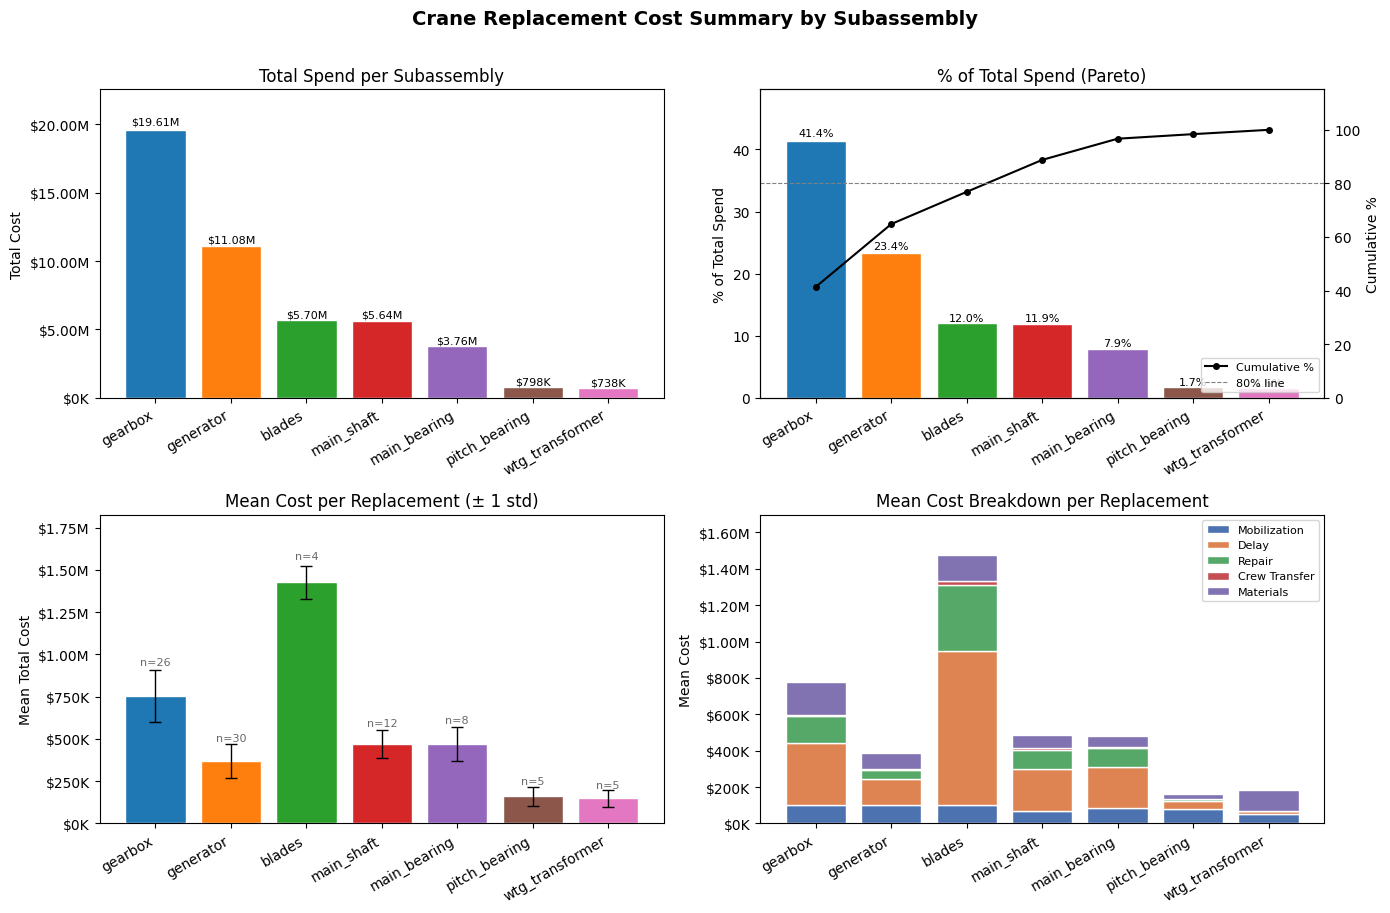

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

def plot_subassembly_cost_summary(df_by_subassembly):
    """
    4-panel figure summarizing crane replacement costs by subassembly.
      1. Total spend by subassembly (bar)
      2. % of total spend (bar)
      3. Mean cost per replacement with std error bars (bar)
      4. Cost distribution per replacement (box)
    """

    # --- Setup ---
    subs = df_by_subassembly.index.tolist()  # already sorted by total_spend desc
    x = np.arange(len(subs))
    colors = plt.cm.tab10.colors

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("Crane Replacement Cost Summary by Subassembly", fontsize=14, fontweight="bold", y=1.01)

    fmt_dollar = mticker.FuncFormatter(lambda v, _: f"${v/1e6:.2f}M" if v >= 1e6 else f"${v/1e3:.0f}K")

    # --- Panel 1: Total spend ---
    ax = axes[0, 0]
    bars = ax.bar(x, df_by_subassembly["total_spend"], color=colors[:len(subs)], edgecolor="white")
    ax.set_title("Total Spend per Subassembly")
    ax.set_ylabel("Total Cost")
    ax.set_xticks(x); ax.set_xticklabels(subs, rotation=30, ha="right")
    ax.yaxis.set_major_formatter(fmt_dollar)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                fmt_dollar(bar.get_height(), None), ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, df_by_subassembly["total_spend"].max() * 1.15)

    # --- Panel 2: % of total spend (Pareto-style) ---
    ax = axes[0, 1]
    pct = df_by_subassembly["pct_of_total_spend"]
    bars = ax.bar(x, pct, color=colors[:len(subs)], edgecolor="white")
    cumulative = pct.cumsum()
    ax2 = ax.twinx()
    ax2.plot(x, cumulative, color="black", marker="o", linewidth=1.5, markersize=4, label="Cumulative %")
    ax2.axhline(80, color="gray", linestyle="--", linewidth=0.8, label="80% line")
    ax2.set_ylabel("Cumulative %")
    ax2.set_ylim(0, 115)
    ax2.legend(fontsize=8, loc="lower right")
    ax.set_title("% of Total Spend (Pareto)")
    ax.set_ylabel("% of Total Spend")
    ax.set_xticks(x); ax.set_xticklabels(subs, rotation=30, ha="right")
    for bar, p in zip(bars, pct):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f"{p:.1f}%", ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, pct.max() * 1.2)

    # --- Panel 3: Mean cost per replacement with std error bars ---
    ax = axes[1, 0]
    means = df_by_subassembly["total_cost_mean"]
    stds  = df_by_subassembly["total_cost_std"].fillna(0)
    n     = df_by_subassembly["n_replacements"]
    bars  = ax.bar(x, means, yerr=stds, color=colors[:len(subs)], edgecolor="white",
                   error_kw=dict(ecolor="black", capsize=4, linewidth=1))
    ax.set_title("Mean Cost per Replacement (± 1 std)")
    ax.set_ylabel("Mean Total Cost")
    ax.set_xticks(x); ax.set_xticklabels(subs, rotation=30, ha="right")
    ax.yaxis.set_major_formatter(fmt_dollar)
    for i, (bar, ni) in enumerate(zip(bars, n)):
        ax.text(bar.get_x() + bar.get_width() / 2,
                (means.iloc[i] + stds.iloc[i]) * 1.02,
                f"n={ni}", ha="center", va="bottom", fontsize=8, color="dimgray")
    ax.set_ylim(0, (means + stds).max() * 1.2)

    # --- Panel 4: Cost breakdown stacked bar ---
    ax = axes[1, 1]
    cost_components = {
        "Mobilization":    "equipment_cost_mobilization_mean",
        "Delay":           "equipment_cost_delay_mean",
        "Repair":          "equipment_cost_repair_mean",
        "Crew Transfer":   "equipment_cost_transferring_crew_mean",
        "Materials":       "materials_cost_mean",
    }
    bottom = np.zeros(len(subs))
    comp_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
    for (label, col), color in zip(cost_components.items(), comp_colors):
        vals = df_by_subassembly[col].fillna(0).values
        ax.bar(x, vals, bottom=bottom, label=label, color=color, edgecolor="white")
        bottom += vals
    ax.set_title("Mean Cost Breakdown per Replacement")
    ax.set_ylabel("Mean Cost")
    ax.set_xticks(x); ax.set_xticklabels(subs, rotation=30, ha="right")
    ax.yaxis.set_major_formatter(fmt_dollar)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_ylim(0, bottom.max() * 1.15)

    plt.tight_layout()
    plt.savefig("subassembly_cost_summary.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_subassembly_cost_summary(df_by_subassembly)